In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import illustris_python as il
import pickle

In [3]:

plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

In [4]:
basePath = '/cosma7/data/dp004/dc-zhan5/TNG300-1'

In [5]:
snapnum=40

In [6]:
fields = ['GroupFirstSub', "GroupSFR", "GroupMass", "GroupNsubs", 
          "GroupPos", "GroupMassType", "GroupBHMass", "Group_M_TopHat200", "Group_M_Crit200", "Group_R_TopHat200"]
header = il.groupcat.loadHeader(f"{basePath}/output", snapnum)
halos = il.groupcat.loadHalos(f"{basePath}/output", snapnum, fields=fields)

In [7]:
mvir = np.log10(halos["Group_M_TopHat200"]*1e10)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [8]:
mfof = np.log10(halos["GroupMass"]*1e10)

In [9]:
mvir_lin = halos["Group_M_TopHat200"]
mfof_lin = halos["GroupMass"]

In [10]:
rvir = halos["Group_R_TopHat200"]/1e3

In [11]:
sfrs = halos["GroupSFR"]

In [85]:
def lognormal(r, sigma, R):
    
    d = R*2
    fr = np.exp(-(np.log(r/d))**2/(2*sigma**2))/(r*sigma*np.sqrt(2*np.pi))
    return fr

In [13]:
logMmin = 12
logMmax = 12.5
mask12 = (mvir>logMmin) & (mvir < logMmax) & (sfrs>0)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:4: RuntimeWarning: divide by zero encountered in log10
  after removing the cwd from sys.path.
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:4: RuntimeWarning: invalid value encountered in true_divide
  after removing the cwd from sys.path.


Text(0, 0.5, 'PDF')

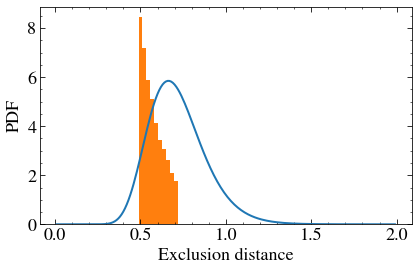

In [14]:
ds = np.arange(0,2, 0.01)
y = lognormal(ds, sigma=0.1,R=0.35)
plt.plot(ds,y)
plt.hist(2*rvir[mask12], density=True)
plt.xlabel("Exclusion distance")
plt.ylabel("PDF")

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:4: RuntimeWarning: divide by zero encountered in log10
  after removing the cwd from sys.path.
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:4: RuntimeWarning: invalid value encountered in true_divide
  after removing the cwd from sys.path.


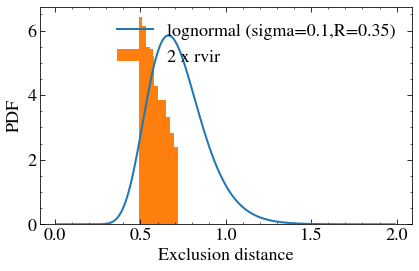

In [15]:
ds = np.arange(0,2, 0.01)
y = lognormal(ds, sigma=0.1,R=0.35)
plt.plot(ds,y, label="lognormal (sigma=0.1,R=0.35)")
plt.hist(2*rvir[mask12], weights=sfrs[mask12], density=True, label="2 x rvir")
plt.xlabel("Exclusion distance")
plt.ylabel("PDF")
plt.legend()

In [16]:
mass_ratio = mfof_lin[mask12]/mvir_lin[mask12]
r_ratio = mass_ratio**(1/3)

In [17]:
import itertools

def sum_combinations(lst):
    sums = [x + y for x, y in itertools.combinations(lst, 2)]
    #sums.append(2*lst)
    return sums


In [18]:
distances = sum_combinations(rvir[mask12]*mass_ratio)

In [93]:
tot_sfr = np.sum(sfrs[mask12])

In [96]:
distance_weights = sum_combinations(sfrs[mask12]/tot_sfr)

In [100]:
print(len(distances))

144372528


In [19]:
ds = np.arange(0,2, 0.01)
y = lognormal(ds, sigma=0.1,R=0.35)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:4: RuntimeWarning: divide by zero encountered in log10
  after removing the cwd from sys.path.
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:4: RuntimeWarning: invalid value encountered in true_divide
  after removing the cwd from sys.path.


/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:4: RuntimeWarning: divide by zero encountered in log
  after removing the cwd from sys.path.
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:4: RuntimeWarning: invalid value encountered in true_divide
  after removing the cwd from sys.path.


Text(0, 0.5, 'PDF')

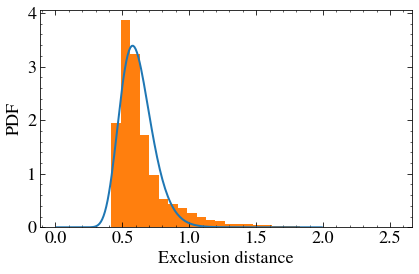

In [44]:
y = lognormal(ds, sigma=0.2,R=0.3)
plt.plot(ds,y)
plt.hist(2*rvir[mask12]*mass_ratio, weights=sfrs[mask12], density=True, bins=30)
#plt.hist(distances[::100000], density=True)
plt.xlabel("Exclusion distance")
plt.ylabel("PDF")

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:4: RuntimeWarning: divide by zero encountered in log
  after removing the cwd from sys.path.
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:4: RuntimeWarning: invalid value encountered in true_divide
  after removing the cwd from sys.path.


Text(0, 0.5, 'PDF')

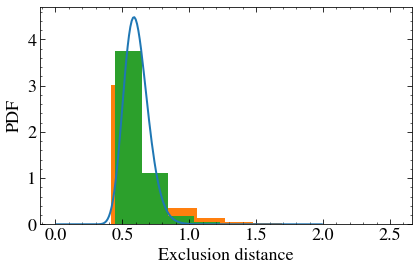

In [40]:
y = lognormal(ds, sigma=0.15,R=0.3)
plt.plot(ds,y)
plt.hist(2*rvir[mask12]*mass_ratio, weights=sfrs[mask12], density=True)
plt.hist(distances[::100000], density=True)
plt.xlabel("Exclusion distance")
plt.ylabel("PDF")

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:4: RuntimeWarning: divide by zero encountered in log
  after removing the cwd from sys.path.
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:4: RuntimeWarning: invalid value encountered in true_divide
  after removing the cwd from sys.path.


Text(0, 0.5, 'PDF')

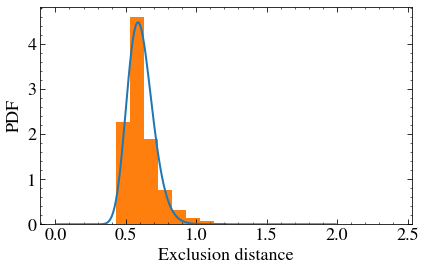

In [45]:
y = lognormal(ds, sigma=0.15,R=0.3)
plt.plot(ds,y)
plt.hist(distances[::100], density=True, bins=20)
plt.xlabel("Exclusion distance")
plt.ylabel("PDF")

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:4: RuntimeWarning: divide by zero encountered in log
  after removing the cwd from sys.path.
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:4: RuntimeWarning: invalid value encountered in true_divide
  after removing the cwd from sys.path.


Text(0, 0.5, 'PDF')

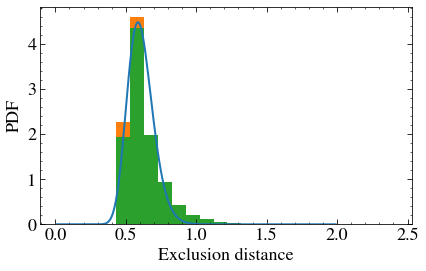

In [99]:
y = lognormal(ds, sigma=0.15,R=0.3)
plt.plot(ds,y)
plt.hist(distances[::100], density=True, bins=20)
plt.hist(distances[::100], density=True, bins=20, weights=distance_weights[::100])
plt.xlabel("Exclusion distance")
plt.ylabel("PDF")

In [88]:
def lognormal_base10(r, sigma, R):
    
    d = R*2
    d = 10**(np.log(d)/np.log(10))
    fr = np.exp(-(np.log10(r/d))**2/(2*sigma**2))/(np.log(10)*r*sigma*np.sqrt(2*np.pi))
    return fr

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:4: RuntimeWarning: divide by zero encountered in log
  after removing the cwd from sys.path.
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:4: RuntimeWarning: invalid value encountered in true_divide
  after removing the cwd from sys.path.
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:5: RuntimeWarning: divide by zero encountered in log10
  """
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:5: RuntimeWarning: invalid value encountered in true_divide
  """


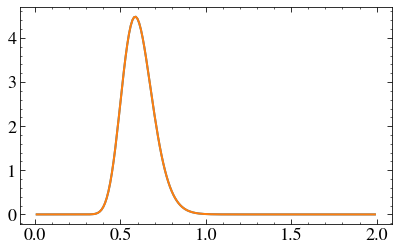

In [89]:
y = lognormal(ds, sigma=0.15,R=0.3)
plt.plot(ds,y)
y = lognormal_base10(ds, sigma=0.15/np.log(10),R=0.3)
plt.plot(ds,y)